In [1]:
import pandas as pd

In [36]:
df = pd.read_pickle("../data/01_df_data_all.pkl")

In [37]:
df_filter = {}

# dependent variables

## action taken

In [38]:
df.groupby('action_taken').size()

action_taken
Approved not accepted                  2493
Denied                                15898
Incomplete                            14306
Originated                            94243
Preapproval approved not accepted      1082
Preapproval denied                     2746
Purchased                            212751
Withdrawn                             25475
dtype: int64

In [39]:
df['reg_uw'] = (df['action_taken']).isin(['Approved not accepted','Originated','Denied']).astype(int)

In [41]:
df.groupby(['reg_uw','action_taken']).size()

reg_uw  action_taken                     
0       Incomplete                            14306
        Preapproval approved not accepted      1082
        Preapproval denied                     2746
        Purchased                            212751
        Withdrawn                             25475
1       Approved not accepted                  2493
        Denied                                15898
        Originated                            94243
dtype: int64

In [43]:
df['denied'] = df['action_taken'].apply(lambda x: 1 if x == 'Denied' else 0)

In [44]:
df.groupby('denied').size()

denied
0    353096
1     15898
dtype: int64

# interest rate

<Axes: >

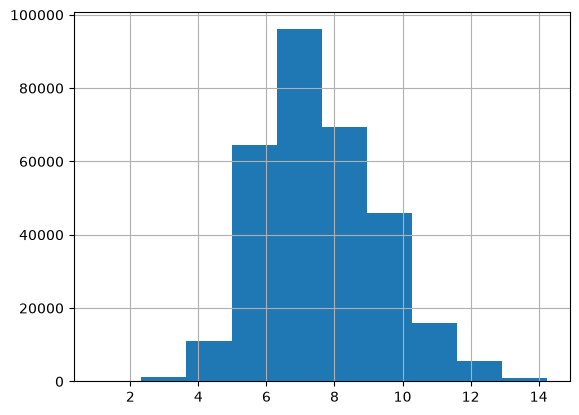

In [45]:
df.interest_rate.hist()

In [46]:
df.groupby('action_taken').agg(
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,mi_rate,mu_rate,mx_rate
action_taken,,,
Approved not accepted,1.875,6.633895,10.240
Denied,NaN,NaN,NaN
Incomplete,NaN,NaN,NaN
Originated,1.000,6.483556,12.740
Preapproval approved not accepted,5.250,6.573542,8.625
Preapproval denied,NaN,NaN,NaN
Purchased,1.000,8.062459,14.250
Withdrawn,NaN,NaN,NaN


In [47]:
df['reg_price'] = (df['action_taken']).isin(['Approved not accepted','Originated']).astype(int)

# Segments

In [69]:
df.groupby('loan_type').agg(
    count=('denied','size'),
    bad_count=('denied','sum'),
    bad_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,bad_count,bad_rate,mi_rate,mu_rate,mx_rate
loan_type,,,,,,
Conventional,354047,14420,0.040729,1.00,7.626819,14.250
FHA insured,11679,1280,0.109598,2.25,5.919252,9.500
VA guaranteed,2975,196,0.065882,2.25,5.901986,8.375


In [68]:
df = df[df['loan_type'].isin(['Conventional','FHA insured','VA guaranteed'])]

In [71]:
df.groupby('loan_purpose').agg(
    count=('denied','size'),
    bad_count=('denied','sum'),
    bad_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,bad_count,bad_rate,mi_rate,mu_rate,mx_rate
loan_purpose,,,,,,
Cash out refinance,157845,3395,0.021508,2.000,8.569662,14.25
Home improvement,7983,1447,0.181260,4.375,7.777903,10.24
Home purchase,137664,7338,0.053304,1.000,6.489491,13.86
Refinance,47036,1624,0.034527,1.750,6.913556,13.99


In [70]:
df = df[df['loan_purpose'].isin(['Cash out refinance','Home improvement','Home purchase','Refinance'])]

# single vs joint

Bin the age reported into one of the ranged provided. Report 8888 if Age is NA or 9999 if No-Co-Applicant




In [57]:
df.groupby("co_applicant_age").size()

co_applicant_age
25-34     19188
35-44     20525
45-54     13735
55-64     12244
65-74      8496
8888     183742
9999     105692
<25        1846
>74        3526
dtype: int64

In [63]:
df['co_applicant_age'].info()

<class 'pandas.Series'>
RangeIndex: 368994 entries, 0 to 368993
Series name: co_applicant_age
Non-Null Count   Dtype
--------------   -----
368994 non-null  str  
dtypes: str(1)
memory usage: 2.8 MB


In [67]:
df["joint_application"] = (
    (
    df["co_applicant_age"]
    .astype(str)
    .str.strip()
) != '9999'
).astype(int)

In [66]:
df["joint_application"].value_counts()

joint_application
1    263302
0    105692
Name: count, dtype: int64

# tests

In [33]:


df.groupby('applicant_race_1').agg(
    count=('denied','size'),
    bad_count=('denied','sum'),
    bad_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,bad_count,bad_rate,mi_rate,mu_rate,mx_rate
applicant_race_1,,,,,,
American Indian Alaska Native,1392,172,0.123563,2.750,6.508016,9.490
Asian,19234,1439,0.074815,2.550,6.162047,10.240
Asian Indian,3382,263,0.077765,3.500,6.047297,9.490
Black African American,13658,1826,0.133695,2.500,6.527246,12.740
Chinese,926,81,0.087473,3.990,6.138369,9.490
Filipino,531,75,0.141243,4.125,6.740768,9.740
Guamanian Chamorro,16,1,0.062500,3.875,6.083636,6.750
Info not provided,16557,1294,0.078154,2.490,6.407736,10.240
Japanese,99,21,0.212121,3.000,6.386200,8.865


In [34]:

df.groupby('applicant_sex').agg(
    count=('denied','size'),
    bad_count=('denied','sum'),
    bad_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,bad_count,bad_rate,mi_rate,mu_rate,mx_rate
applicant_sex,,,,,,
Both male female,115,4,0.034783,4.500,6.535977,8.990
Female,64758,5902,0.091139,1.000,6.481881,10.365
Info not provided,5250,334,0.063619,2.875,6.359478,9.740
Male,110548,9480,0.085755,1.875,6.447189,12.740
Not applicable,188323,178,0.000945,1.000,8.291993,14.250


In [35]:

df.groupby('applicant_age_above_62').agg(
    count=('denied','size'),
    bad_count=('denied','sum'),
    bad_rate=('denied','mean'),
    mi_rate=('interest_rate','min'),
    mu_rate=('interest_rate','mean'),
    mx_rate=('interest_rate','max')
)

,count,bad_count,bad_rate,mi_rate,mu_rate,mx_rate
applicant_age_above_62,,,,,,
No,146201,11916,0.081504,1.000,6.425202,12.74
Yes,34470,3804,0.110357,2.375,6.602917,10.24
